In [111]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
from calibration import lifetime_to_temperature_201112
from scipy.optimize import curve_fit
import seaborn as sns
from PIL import Image
import scipy as sp
from draw_graph import Scatter
from matplotlib.backends.backend_pdf import PdfPages

In [112]:
file_path = glob.glob('./cyto/2009??_IRheating_lin22.6_100mW_5000ms_26/*.csv')
file_path.sort()

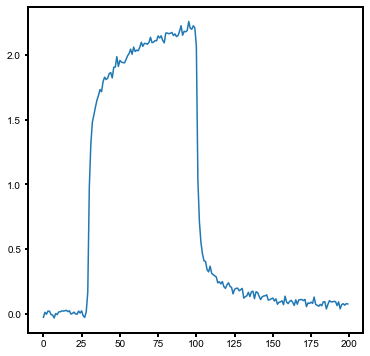

In [113]:
#t=0で切り取る
plt.figure(figsize = (6, 6))
result_cyto = 0
data_set_cyto = pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    lifetime = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-100: index+100]
    result_cyto += lifetime
    data_set_cyto = pd.concat([data_set_cyto, pd.DataFrame(lifetime)], axis = 1)
    
result_cyto = result_cyto/len(file_path)
result_cyto = result_cyto - np.mean(result_cyto[:10])
result_cyto = result_cyto
plt.plot(result_cyto)
plt.show()

In [114]:
(data_set_cyto - data_set_cyto.iloc[:10, :].mean()).to_csv('cyto_all.csv')

In [115]:
file_path = glob.glob('./nuc/2009??_IRheating_lin22.6_100mW_5000ms_26/*.csv')
file_path.sort()

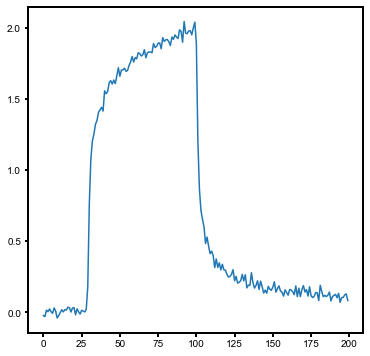

In [116]:
#t=0で切り取る
plt.figure(figsize = (6, 6))
result_nuc = 0
data_set_nuc = pd.DataFrame()

for path in file_path:
    data = np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 3])
    diff = (pd.DataFrame(data) - pd.DataFrame(data[1:]))[0]
    index = np.argmax(diff)
    lifetime = lifetime_to_temperature_201112(np.float32(pd.read_csv(path, sep = '\t').iloc[1:, 1]))[index-100: index+100]
    result_nuc += lifetime
    data_set_nuc = pd.concat([data_set_nuc, pd.DataFrame(lifetime)], axis = 1)
    
result_nuc = result_nuc/len(file_path)
result_nuc = result_nuc - np.mean(result_nuc[:10])
result_nuc = result_nuc
plt.plot(result_nuc)
plt.show()

In [117]:
(data_set_nuc - data_set_nuc.iloc[:10, :].mean()).to_csv('nuc_all.csv')

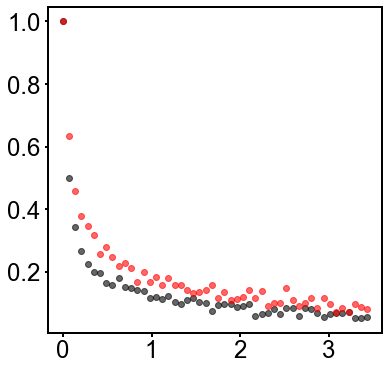

In [118]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(labelsize=24)
result_cyto_cut = result_cyto[100:150]
result_nuc_cut = result_nuc[100:150]
time = [i*0.07 for i in range(len(result_cyto_cut))]
plt.plot(time, result_cyto_cut/max(result_cyto_cut), alpha = 0.6, color = 'black', marker = 'o', linewidth = 0)
plt.plot(time, result_nuc_cut/max(result_nuc_cut), alpha = 0.6, color = 'red', marker = 'o', linewidth = 0)
plt.show()

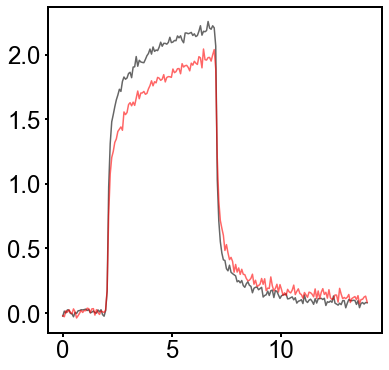

In [119]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(labelsize=24)
time = [i*0.07 for i in range(len(result_cyto))]
plt.plot(time, result_cyto, alpha = 0.6, color = 'black')
plt.plot(time, result_nuc, alpha = 0.6, color = 'red')
plt.show()

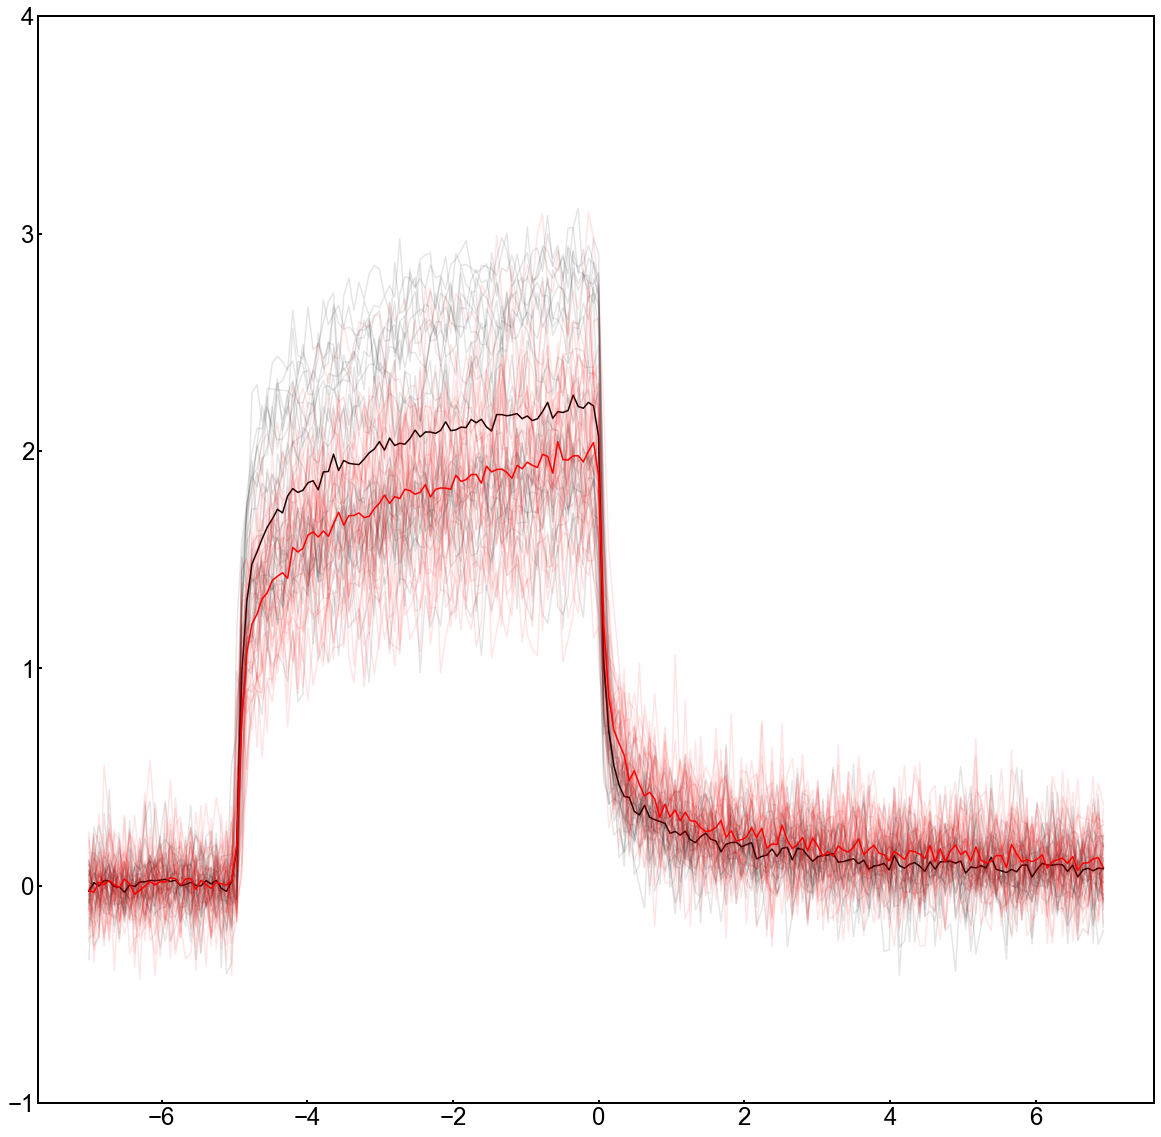

In [120]:
fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 24)

time = [0.07*(i-100) for i in range(len(result_cyto))]

plt.plot(time, result_cyto, color = 'black')
plt.plot(time, data_set_cyto - data_set_cyto.iloc[:10, :].mean(), color = 'black', alpha = 0.1)
plt.plot(time, result_nuc, color = 'red')
plt.plot(time, data_set_nuc - data_set_nuc.iloc[:10, :].mean(), color = 'red', alpha = 0.1)

plt.ylim(-1, 4)
plt.show()


#pdfのセーブ
pp = PdfPages('./Fig3e_outline.pdf')
pp.savefig(fig)
pp.close()

#平均値の保存
pd.DataFrame(result_cyto).to_csv('cyto.csv')
pd.DataFrame(result_nuc).to_csv('nuc.csv')

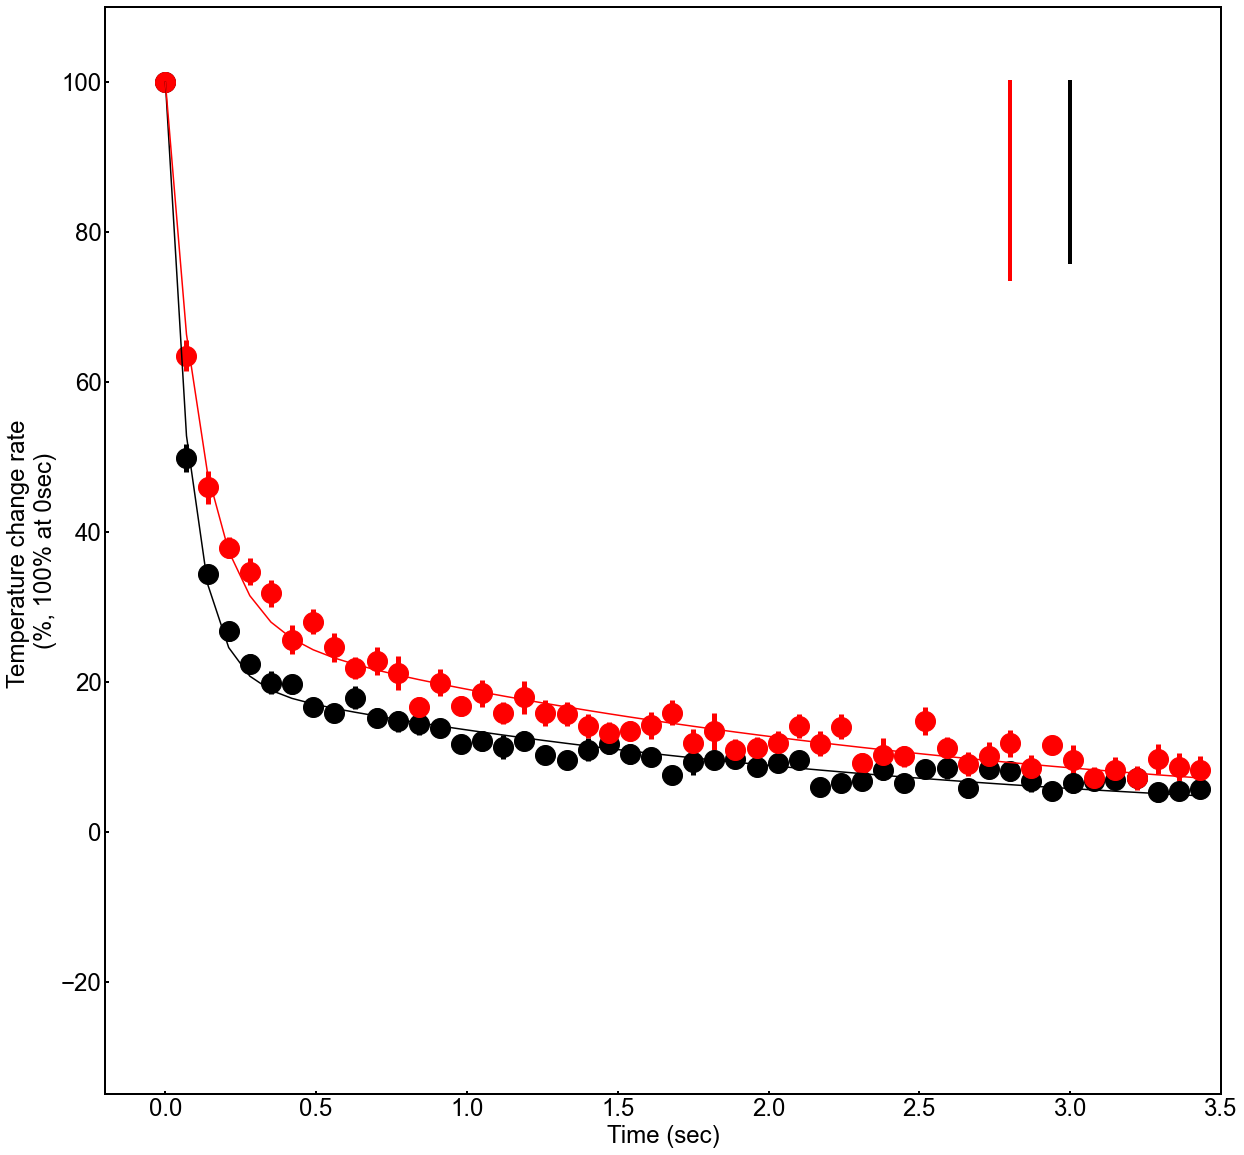

In [121]:
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)

time_cyto = [(i)*0.07 for i in range(len(result_cyto_cut))]
time_nuc = [(i)*0.07 for i in range(len(result_nuc_cut))]

#1˚Cを示すバーを挿入
normal_bar = [100- 50/max(result_cyto_cut)*i/100 for i in range(100)]
normal_bar_pos = [3.0 for i in range(len(normal_bar))]
plt.plot(normal_bar_pos, normal_bar, linewidth = 4, color = 'black', linestyle = '-')

#1˚Cを示すバーを挿入
nuc_bar = [100- 50/max(result_nuc_cut)*i/100 for i in range(100)]
nuc_bar_pos = [2.8 for i in range(len(nuc_bar))]
plt.plot(nuc_bar_pos, nuc_bar, linewidth = 4, color = 'red', linestyle = '-')

#SEMを計算
data_set_cyto = data_set_cyto - np.mean(data_set_cyto.iloc[:10, :])
data_set_cyto = data_set_cyto/data_set_cyto.iloc[100, :]*100
sem_cyto = data_set_cyto.sem(axis = 1)
sem_cyto[0] = 0

data_set_nuc = data_set_nuc - np.mean(data_set_nuc.iloc[:10, :])
data_set_nuc = data_set_nuc/data_set_nuc.iloc[100, :]*100
sem_nuc = data_set_nuc.sem(axis = 1)
sem_nuc[0] = 0

result_cyto_cut = result_cyto_cut/result_cyto_cut[0]
result_nuc_cut = result_nuc_cut/result_nuc_cut[0]

plt.errorbar(time_cyto, result_cyto_cut*100, yerr = np.ravel(sem_cyto)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.errorbar(time_nuc, result_nuc_cut*100, yerr = np.ravel(sem_nuc)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time_cyto, result_cyto_cut*100, color = 'black', markersize = 20, marker = 'o', linewidth = 0)
plt.plot(time_nuc, result_nuc_cut*100, color = 'red', markersize = 20, marker = 'o', linewidth = 0)
plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('Temperature change rate \n(%, 100% at 0sec)', fontsize = 24)

#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
fitting_cyto = curve_fit(relaxation, time_cyto, result_cyto_cut)[0]
fitting_nuc = curve_fit(relaxation, time_nuc, result_nuc_cut)[0]

#fitting結果の図示
plt.plot(time_cyto, relaxation(np.ravel(time_cyto), fitting_cyto[0], fitting_cyto[1], fitting_cyto[2])*100, color = 'black')
plt.plot(time_nuc, relaxation(np.ravel(time_nuc), fitting_nuc[0],fitting_nuc[1], fitting_nuc[2])*100, color = 'red')

#pdfのセーブ
pp = PdfPages('./Fig3e_relaxation.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(result_cyto_cut).to_csv('cyto_normalized.csv')
pd.DataFrame(result_nuc_cut).to_csv('nuc_normalized.csv')
pd.DataFrame(sem_cyto[100:150]).to_csv('sem_cyto.csv')
pd.DataFrame(sem_nuc[100:150]).to_csv('sem_nuc.csv')

In [122]:
#welchのt検定
sum_cyto = data_set_cyto.iloc[102:150].sum().values
sum_nuc = data_set_nuc.iloc[102:150].sum().values
sp.stats.ttest_ind(sum_cyto, sum_nuc, equal_var = False)

Ttest_indResult(statistic=-5.950931761456911, pvalue=1.711624645180283e-07)

In [123]:
sem_nuc_bar = (sum_nuc*0.07).std(ddof = 1)/np.sqrt(len(sum_nuc))
sem_cyto_bar = (sum_cyto*0.07).std(ddof = 1)/np.sqrt(len(sum_cyto))

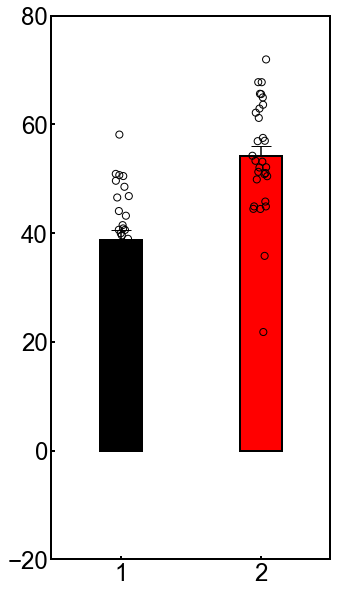

In [124]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_nuc_ave = np.average(sum_nuc*0.07)
sum_cyto_ave = np.average(sum_cyto*0.07)


plt.bar(2, sum_nuc_ave, yerr = [[0], [sem_nuc_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_nuc)) 
plt.scatter(x, sum_nuc*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)
plt.bar(1, sum_cyto_ave, yerr = [[0], [sem_cyto_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_cyto)) 
plt.scatter(x, sum_cyto*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)


plt.ylim(-20, 80)
plt.xlim(0.5, 2.5)

#pdfのセーブ
pp = PdfPages('./Fig3e_ralaxation_bar.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(sum_cyto*0.07).to_csv('AUC_cyto_all.csv')
pd.DataFrame(sum_nuc*0.07).to_csv('AUC_nuc_all.csv')

In [125]:
print(sum_cyto_ave)
print(sem_cyto_bar)
print(sum_nuc_ave)
print(sem_nuc_bar)

38.788883
1.7186289856145676
54.18754
1.9344259566848518
